# Label flipping on a linear classifier

**Question.** How fast does a logistic-regression classifier lose accuracy on clean test data as an
attacker flips a growing share of its training labels?

**Threat model.**
- Attacker's goal: poisoning, to lower the model's accuracy at test time.
- Attacker's access: can change the labels of a random share of the training rows, not the features.
- Attacker's knowledge: none needed; the flips are random.
- Defence measured: none here (a data-sanitisation defence is the natural follow-up).

## 0. Setup
 Two Gaussian blobs in two dimensions (1,000 points, 70/30 split), logistic regression,
seed 1337, CPU. The flips are random, so this is the weakest form of the attack; a targeted flip
near the boundary would do more damage per flipped label.


In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from pipeline import SEED, train_model, evaluate_model, flip_labels, plot_2d, log_result, load_results

np.random.seed(SEED)
EXPERIMENT = "label_flipping_blobs"

## 1. Data

train 700 rows, test 300 rows, classes [0 1]


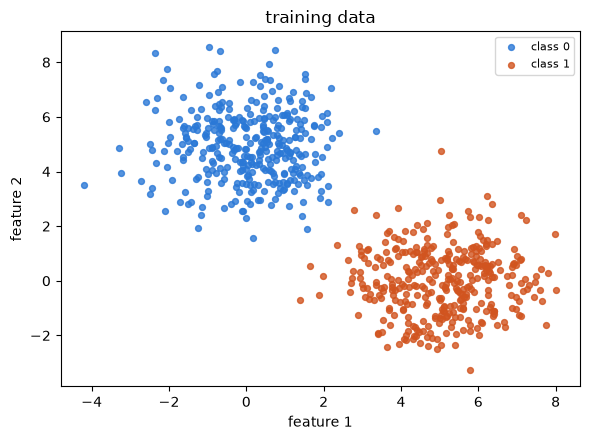

In [2]:
X, y = make_blobs(n_samples=1000, centers=[(0, 5), (5, 0)], n_features=2, cluster_std=1.25, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
print(f"train {X_train.shape[0]} rows, test {X_test.shape[0]} rows, classes {np.unique(y)}")
plot_2d(X_train, y_train, title="training data")

## 2. Baseline

Training logistic_regression...
Training complete
baseline accuracy on clean test data: 0.993


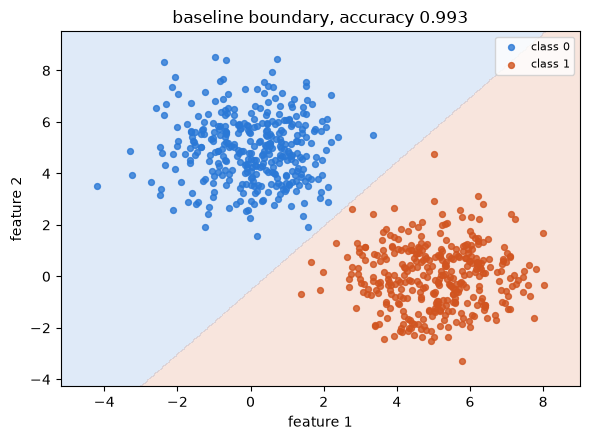

In [3]:
baseline = train_model("logistic_regression", X_train, y_train)
baseline_accuracy = evaluate_model(baseline, X_test, y_test)["accuracy"]
print(f"baseline accuracy on clean test data: {baseline_accuracy:.3f}")
plot_2d(X_train, y_train, title=f"baseline boundary, accuracy {baseline_accuracy:.3f}", model=baseline)

## 3. Attack

Flip a share of the training labels, retrain, and score on the clean test set. The sweep runs from 0% to 50%.

Training logistic_regression...
Training complete


Training logistic_regression...
Training complete
Training logistic_regression...
Training complete
Training logistic_regression...
Training complete
Training logistic_regression...
Training complete
Training logistic_regression...
Training complete
Training logistic_regression...
Training complete


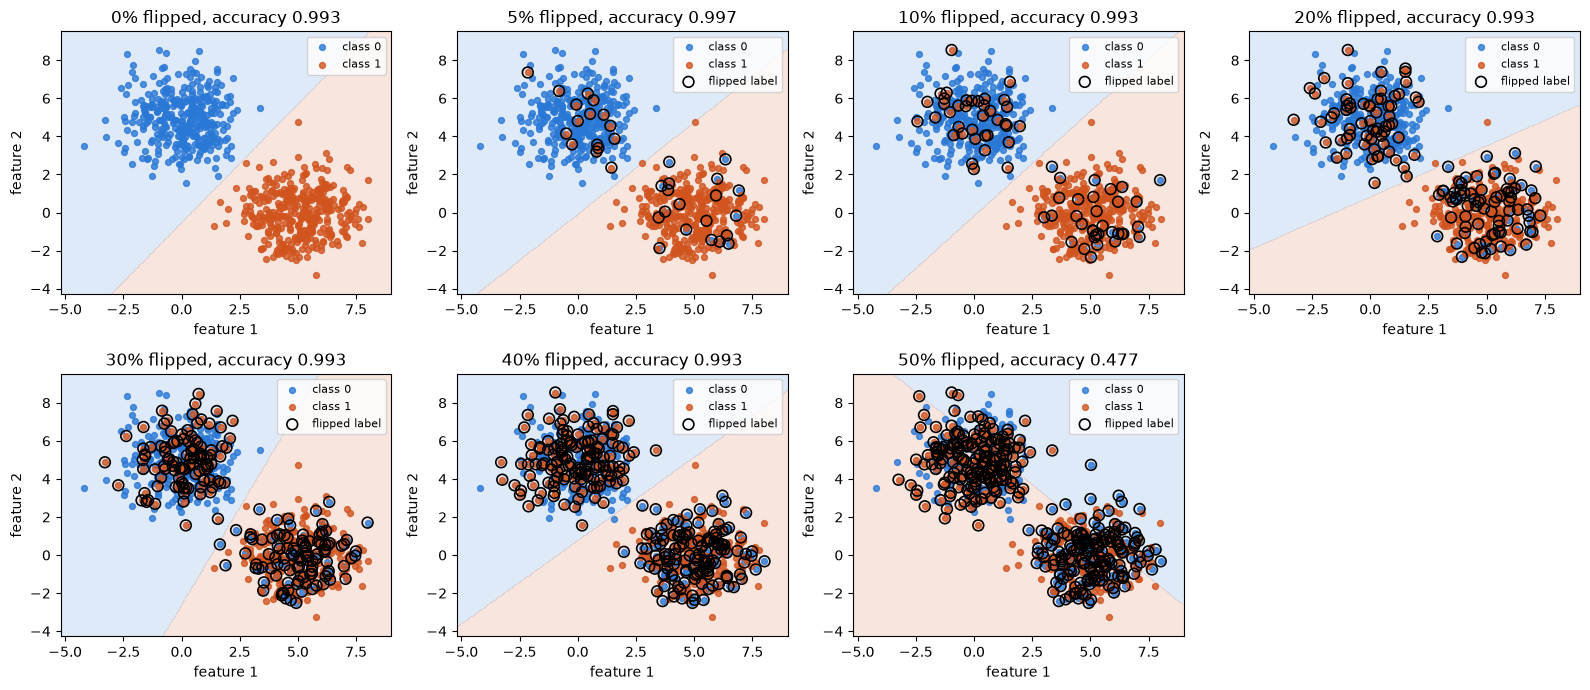

In [4]:
rates = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
rows = []
fig, axes = plt.subplots(2, 4, figsize=(16, 7)); axes = axes.ravel()
for i, rate in enumerate(rates):
    y_poisoned, flipped = flip_labels(y_train, rate, seed=SEED)
    model = train_model("logistic_regression", X_train, y_poisoned)
    accuracy = evaluate_model(model, X_test, y_test)["accuracy"]
    rows.append({"poison_rate": rate, "labels_flipped": len(flipped), "accuracy": accuracy})
    log_result(EXPERIMENT, condition="random_flip", poison_rate=rate, labels_flipped=len(flipped), accuracy=accuracy)
    plot_2d(X_train, y_poisoned, title=f"{rate:.0%} flipped, accuracy {accuracy:.3f}", model=model,
            highlight=flipped, ax=axes[i])
axes[-1].axis("off"); fig.tight_layout(); plt.show()

## 4. Defence

Not measured here. The natural next step is to drop training points whose label disagrees with their nearest neighbours and repeat the sweep.

## 5. Results

In [5]:
results = pd.DataFrame(rows)
results["drop_from_baseline"] = baseline_accuracy - results["accuracy"]
results

,poison_rate,labels_flipped,accuracy,drop_from_baseline
0,0.00,0,0.993333,0.000000
1,0.05,35,0.996667,-0.003333
2,0.10,70,0.993333,0.000000
3,0.20,140,0.993333,0.000000
4,0.30,210,0.993333,0.000000
5,0.40,280,0.993333,0.000000
6,0.50,350,0.476667,0.516667


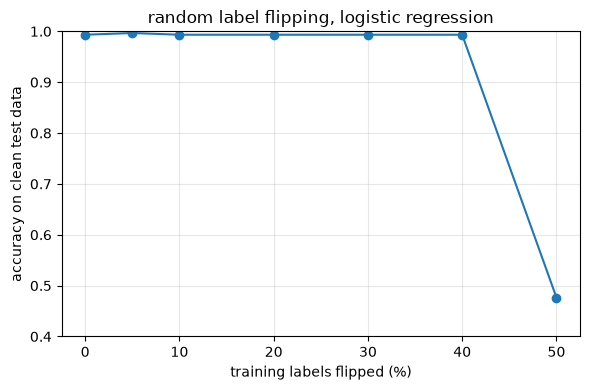

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(results["poison_rate"] * 100, results["accuracy"], marker="o")
plt.xlabel("training labels flipped (%)"); plt.ylabel("accuracy on clean test data"); plt.ylim(0.4, 1.0)
plt.title("random label flipping, logistic regression"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()